In [112]:
# Header of the CSV files
# Date	Time	time_passed_since_start	ADS Reading 1	Current 1	ADS Reading 2	Current 2	ADS Reading 3	Volts 1	Lost Data

In [ ]:
# Imports
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
units_to_voltage = 0.0001875  # Each unit corresponds to 0.0001875 volts

In [ ]:
current_directory = Path.cwd().parent
discharge_file_dir = Path.joinpath(current_directory, "Data Start Point")

files = [f for f in discharge_file_dir.iterdir() if f.is_file()]    # Names are sorted by date already
for fileName in files:
    print(f"Found: {fileName}")

Found: c:\Users\Kor\Documents\GitHub\Proa-II-Electrical-Setup\Calibration Data 2\Data\Data Start Point\2026-04-15_data_log.csv
Found: c:\Users\Kor\Documents\GitHub\Proa-II-Electrical-Setup\Calibration Data 2\Data\Data Start Point\2026-05-06_data_log.csv
Found: c:\Users\Kor\Documents\GitHub\Proa-II-Electrical-Setup\Calibration Data 2\Data\Data Start Point\2026-05-08_data_log.csv


In [ ]:
output_file_name = Path.joinpath(discharge_file_dir, "compiled_output.csv")

def create_output_file(override=False, csv_data=None):
    if override and Path.exists(output_file_name):
        Path.unlink(output_file_name)
    
    if csv_data is not None:
        csv_data.to_csv(output_file_name, mode='a', header=not Path.exists(output_file_name), index=False)

In [256]:
def drop_columns(df, columns=['Date', 'Time', 'Current 1', 'Current 2', 'Volts 1']):
    return df.drop(columns=columns)

In [257]:
def median_smoothing(*series, window_size=5):
    smoothed_series = [[] for _ in range(len(series))] 
    for i in range(len(series[0])):
        if i % 10000 == 0:
            print(f"Processing line {i}/{len(series[0])}", end="\r")
        
        start_index = max(0, i - window_size // 2)
        end_index = min(len(series[0]), i + window_size // 2 + 1)
        
        for index in range(len(series)):
            median_value = series[index][start_index:end_index].median()
            smoothed_series[index].append(median_value)
    return smoothed_series

In [258]:
def translate_time(time_series):
    offset = 0
    translated = [time_series.iloc[0]]

    for i in range(1, len(time_series)):
        if time_series.iloc[i] < time_series.iloc[i-1]:
            print(f"Time reset detected at index {i}. Adding offset of {time_series.iloc[i-1]} seconds.")
            offset += time_series.iloc[i-1]

        translated.append(time_series.iloc[i] + offset)

    return translated


In [259]:
minimised_ratio = 12.153061224489797    # From voltage minimisation folder

def calibrate_voltage(ads_reading):
    return ads_reading * units_to_voltage * minimised_ratio    

In [260]:
def calibrate_current(ads_reading):
    a=-0.6572687402320041
    b=334.34596195700385
    c=-ads_reading
    return (-b + (b**2 - 4 * a * c)**0.5) / (2 * a)

In [261]:
cleaned_dfs = [None] * len(files)

In [266]:
SELECT = [0,1,2,3]  # Choose which files to process
CALIBRATED_VOLTAGE_THRESHOLD = 15  # Only keep data points where calibrated voltage is above this threshold

for index in range(len(files)):
    if index not in SELECT:
        continue
    file = files[index]
    
    df = pd.read_csv(file)
    
    # Dropped precalculated columns and other irrelevant columns. Only keep raw ADS reading 1, 2, 3 and time passed since start for calibration.
    cleaned_df = drop_columns(df)
    cleaned_df.drop_duplicates(inplace=True)
    print("Removed duplicated rows: {} \t\t\t\t\t\t\t\t\t\t\t\t".format(df.shape[0] - cleaned_df.shape[0]))
    
    cleaned_df['time_passed_since_start'] = translate_time(cleaned_df['time_passed_since_start'])
    
    total_lost_data = df['Lost Data'][1:].sum() # Remove first row which accumulates error from waiting to connect
    print("Total Lost Data for file {}: {}\t\t\t\t\t\t".format(file.name, total_lost_data))

    # Calibrate ADS reading
    print("Processing ADS 1:")
    [cleaned_df['ADS Reading 1 (Smoothed)'], cleaned_df['ADS Reading 2 (Smoothed)'], cleaned_df['ADS Reading 3 (Smoothed)']] = median_smoothing(
        cleaned_df['ADS Reading 1'],
        cleaned_df['ADS Reading 2'],
        cleaned_df['ADS Reading 3']
    )

    # Calibrate voltage reading
    cleaned_df['Calibrated Voltage'] = cleaned_df['ADS Reading 3'].apply(calibrate_voltage)
    cleaned_df = cleaned_df[cleaned_df['Calibrated Voltage'] >= CALIBRATED_VOLTAGE_THRESHOLD]
    
    print("Final shape: {}\t\t\t\t\t\t\t\t\t\t".format(cleaned_df.shape))
    cleaned_dfs[index] = cleaned_df
    print("="*50)
    

Removed duplicated rows: 0 												
Total Lost Data for file 2026-04-15_data_log.csv: 706						
Processing ADS 1:
Final shape: (225040, 9)										
Removed duplicated rows: 0 												
Time reset detected at index 8640. Adding offset of 390036 seconds.
Total Lost Data for file 2026-05-06_data_log.csv: 1030						
Processing ADS 1:
Final shape: (206000, 9)										
Removed duplicated rows: 0 												
Total Lost Data for file 2026-05-08_data_log.csv: 0						
Processing ADS 1:
Final shape: (235660, 9)										


In [267]:
print(cleaned_dfs[0].head())

   time_passed_since_start  ADS Reading 1  ADS Reading 2  ADS Reading 3  \
0                      0.0             -9            -87          10011   
1                     63.0            -12            -87          10012   
2                     94.0            -12            -91          10011   
3                    126.0            -12            -88          10012   
4                    157.0            -15            -82          10012   

   Lost Data  ADS Reading 1 (Smoothed)  ADS Reading 2 (Smoothed)  \
0          0                     -12.0                     -87.0   
1          0                     -12.0                     -87.5   
2          0                     -12.0                     -87.0   
3          0                     -12.0                     -87.0   
4          0                     -12.0                     -85.0   

   ADS Reading 3 (Smoothed)  Calibrated Voltage  
0                   10011.0           22.812055  
1                   10011.5           22

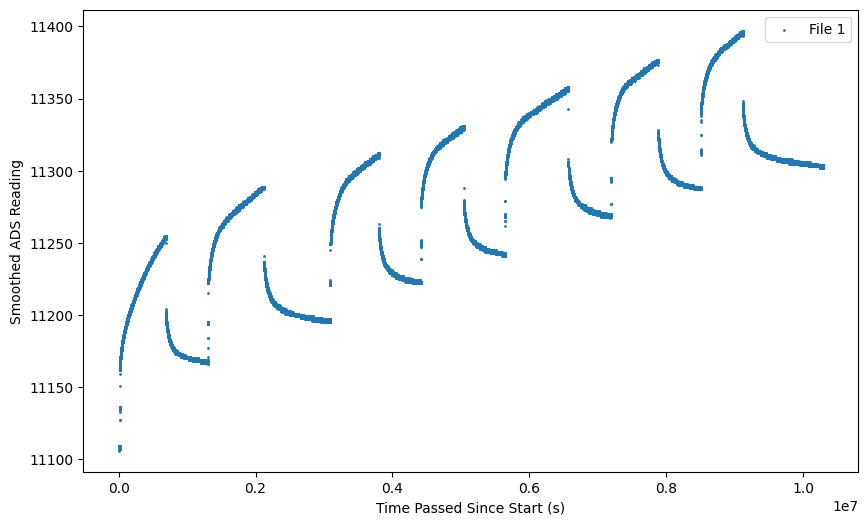

In [270]:
plt.figure(figsize=(10, 6))
#plt.scatter(cleaned_dfs[0]['time_passed_since_start'], cleaned_dfs[0]['ADS Reading 1 (Smoothed)'], s=1, label='File 1')
#plt.scatter(cleaned_dfs[0]['time_passed_since_start'], cleaned_dfs[0]['ADS Reading 2 (Smoothed)'], s=1, label='File 1')
plt.scatter(cleaned_dfs[2]['time_passed_since_start'], cleaned_dfs[2]['ADS Reading 3 (Smoothed)'], s=1, label='File 1')
plt.xlabel('Time Passed Since Start (s)')
plt.ylabel('Smoothed ADS Reading')
plt.legend()
plt.show()

In [271]:
SELECT = [0,1,2,3]

for index in range(len(cleaned_dfs)):
    if index not in SELECT:
        continue
    cleaned_df = cleaned_dfs[index]
    
    # Offset ads1 and ads2 only
    zeroed_ads1 = []
    zeroed_ads2 = []
    ads1_offset = 0
    ads2_offset = 0
    ads1_started = False
    ads2_started = False
    
    cleaned_df["ADS Reading 1 (Smoothed and Offset)"] = cleaned_df["ADS Reading 1 (Smoothed)"]
    cleaned_df["ADS Reading 2 (Smoothed and Offset)"] = cleaned_df["ADS Reading 2 (Smoothed)"]
    
    for i in range(len(cleaned_df)):
        if i % 10000 == 0:
            print(f"Processing index {i}/{len(cleaned_df)} for file {index + 1} / {len(cleaned_dfs)}", end="\r")
        
        # Get a list of reading when no current is flowing
        threshold = 100  # Threshold for determining if current is flowing, can be adjusted based on data distribution
        if cleaned_df["ADS Reading 1 (Smoothed and Offset)"].iloc[i] < threshold:
            if ads1_started:    # Reset the list if back to zero to recalibrate when current stops flowing again
                print("ADS Reading 1 dropped below threshold at index {}. Resetting offset calibration.".format(i))
                zeroed_ads1 = []
                ads1_offset = 0
                ads1_started = False
                
            zeroed_ads1.append(cleaned_df["ADS Reading 1 (Smoothed and Offset)"].iloc[i])
        if cleaned_df["ADS Reading 2 (Smoothed and Offset)"].iloc[i] < threshold:
            if ads2_started:
                print("ADS Reading 2 dropped below threshold at index {}. Resetting offset calibration.".format(i))
                zeroed_ads2 = [] 
                ads2_offset = 0
                ads2_started = False
                
            zeroed_ads2.append(cleaned_df["ADS Reading 2 (Smoothed and Offset)"].iloc[i])
        
        # Offset the reading when current is flowing to correct for any drift in the sensor. 
        # Only offset when current is flowing to prevent outlier readings.
        if cleaned_df["ADS Reading 1 (Smoothed and Offset)"].iloc[i] >= threshold:
            if len(zeroed_ads1) > 10:
                ads1_started = True
                # At least 10 reading to get avergage offset to prevent outlier       
                ads1_offset = sum(zeroed_ads1) / len(zeroed_ads1)
                
                cleaned_df['ADS Reading 1 (Smoothed and Offset)'] = cleaned_df['ADS Reading 1 (Smoothed and Offset)'] - ads1_offset
                zeroed_ads1 = []
                print("Rezeroing offset at index {}: ads1 offset {}".format(i, ads1_offset))
        if cleaned_df["ADS Reading 2 (Smoothed and Offset)"].iloc[i] >= threshold:
            if len(zeroed_ads2) > 10:
                ads2_started = True
                # At least 10 reading to get avergage offset to prevent outlier       
                ads2_offset = sum(zeroed_ads2) / len(zeroed_ads2)
                
                cleaned_df['ADS Reading 2 (Smoothed and Offset)'] = cleaned_df['ADS Reading 2 (Smoothed and Offset)'] - ads2_offset
                zeroed_ads2 = []
                print("Rezeroing offset at index {}: ads2 offset {}".format(i, ads2_offset))


Rezeroing offset at index 865: ads2 offset -83.38439306358381
Rezeroing offset at index 866: ads1 offset -2.274826789838337
ADS Reading 1 dropped below threshold at index 880. Resetting offset calibration.
Rezeroing offset at index 925: ads1 offset 88.27482678983833
ADS Reading 1 dropped below threshold at index 926. Resetting offset calibration.
ADS Reading 2 dropped below threshold at index 931. Resetting offset calibration.
Rezeroing offset at index 1184: ads1 offset -80.96511627906976
Rezeroing offset at index 1184: ads2 offset 75.91798990152837
ADS Reading 1 dropped below threshold at index 24073. Resetting offset calibration.
ADS Reading 2 dropped below threshold at index 24073. Resetting offset calibration.
Rezeroing offset at index 52760: ads2 offset 8.601830359038606
Rezeroing offset at index 52761: ads1 offset -95.34905689438648
ADS Reading 1 dropped below threshold at index 71406. Resetting offset calibration.
ADS Reading 2 dropped below threshold at index 71406. Resetting o

In [272]:
SELECT = [0,1,2,3]

for index in range(len(cleaned_dfs)):
    if index not in SELECT:
        continue
    cleaned_df = cleaned_dfs[index]
    
    cleaned_df['Calibrated Current 1'] = cleaned_df['ADS Reading 1 (Smoothed and Offset)'].apply(calibrate_current)
    cleaned_df['Calibrated Current 2'] = cleaned_df['ADS Reading 2 (Smoothed and Offset)'].apply(calibrate_current)

In [273]:
# Shift time to be continuous across files
prev_end_time = 0
for i in range(len(cleaned_dfs)):
    print(f"Processing file {i + 1} / {len(cleaned_dfs)} for time translation.\t\t")
    df = cleaned_dfs[i]

    file_start_time = df['time_passed_since_start'].iloc[0]
    translated_time = df['time_passed_since_start'].copy()
    for row in range(1, len(df)):
        if row % 10000 == 0:
            print(f"Processing row {row} / {len(cleaned_dfs[i])} for file {i + 1} / {len(cleaned_dfs)}\t\t", end="\r")
            
        if df['time_passed_since_start'].iloc[row] - df['time_passed_since_start'].iloc[row-1] > (2 *60*1000):
            shift_time = df['time_passed_since_start'].iloc[row] - df['time_passed_since_start'].iloc[row-1]
            print(f"Jump from {df['time_passed_since_start'].iloc[row-1]} ms to {df['time_passed_since_start'].iloc[row]} ms at index {row} in file {i + 1} / {len(cleaned_dfs)}. Shifting time by {shift_time/1000} s.")
            translated_time[row:] = translated_time[row:] - shift_time
            
    translated_time = translated_time - file_start_time + prev_end_time + 1000  # Add 1 second gap between files to prevent overlap
    df['Translated Time'] = translated_time
    prev_end_time = df['Translated Time'].iloc[-1]

Processing file 1 / 3 for time translation.		
Processing file 2 / 3 for time translation.				
Processing file 3 / 3 for time translation.				


In [274]:
print(cleaned_dfs[0].head())

   time_passed_since_start  ADS Reading 1  ADS Reading 2  ADS Reading 3  \
0                      0.0             -9            -87          10011   
1                     63.0            -12            -87          10012   
2                     94.0            -12            -91          10011   
3                    126.0            -12            -88          10012   
4                    157.0            -15            -82          10012   

   Lost Data  ADS Reading 1 (Smoothed)  ADS Reading 2 (Smoothed)  \
0          0                     -12.0                     -87.0   
1          0                     -12.0                     -87.5   
2          0                     -12.0                     -87.0   
3          0                     -12.0                     -87.0   
4          0                     -12.0                     -85.0   

   ADS Reading 3 (Smoothed)  Calibrated Voltage  \
0                   10011.0           22.812055   
1                   10011.5           

In [277]:

combined_df = pd.concat([cleaned_dfs[i] for i in range(len(cleaned_dfs))], ignore_index=True)
combined_df['Translated Time (minutes)'] = combined_df['Translated Time'] / (1000 * 60)  # Convert ms to minutes

print(combined_df.shape)
print(combined_df.head())

(666700, 15)
   time_passed_since_start  ADS Reading 1  ADS Reading 2  ADS Reading 3  \
0                      0.0             -9            -87          10011   
1                     63.0            -12            -87          10012   
2                     94.0            -12            -91          10011   
3                    126.0            -12            -88          10012   
4                    157.0            -15            -82          10012   

   Lost Data  ADS Reading 1 (Smoothed)  ADS Reading 2 (Smoothed)  \
0          0                     -12.0                     -87.0   
1          0                     -12.0                     -87.5   
2          0                     -12.0                     -87.0   
3          0                     -12.0                     -87.0   
4          0                     -12.0                     -85.0   

   ADS Reading 3 (Smoothed)  Calibrated Voltage  \
0                   10011.0           22.812055   
1                   10011

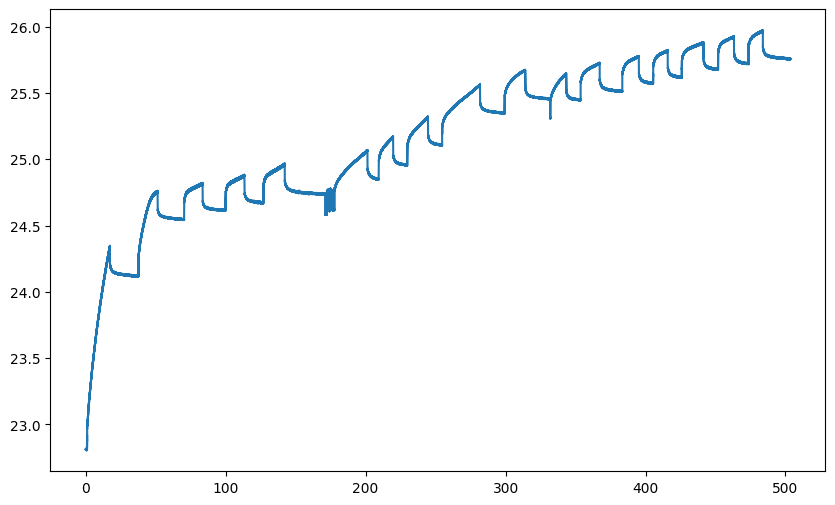

In [278]:
plt.figure(figsize=(10, 6))
plt.plot(combined_df['Translated Time (minutes)'], combined_df['Calibrated Voltage'], label='Calibrated Voltage')
plt.show()

Mean Absolute Error non-offset values (MAE): 83.91181640917954
Mean Absolute Error for offset values (MAE): 43.92100784882944
Mean Error for non-offset values: -69.66778611069446
Mean Error for offset values: -7.849678100093944


C:\Users\Kor\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


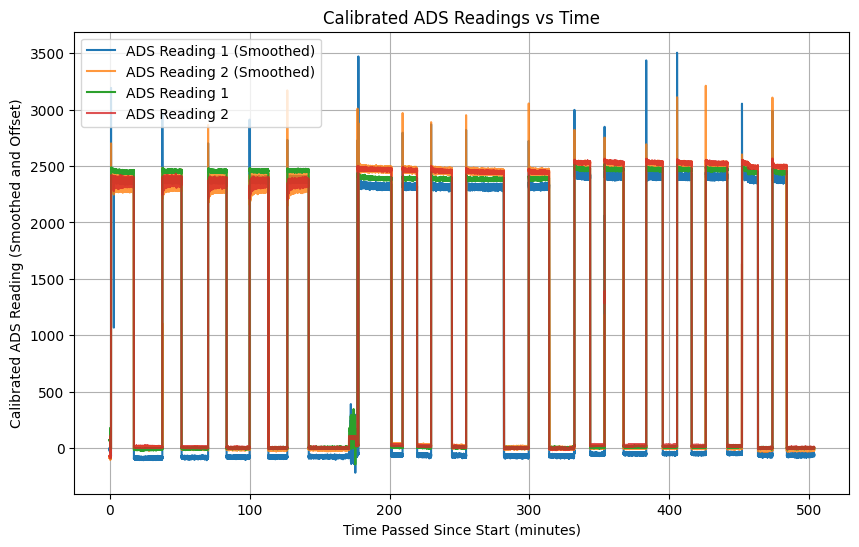

In [279]:
# MAE for ADS1 and ADS2
mean_abs_sum = sum(abs(combined_df["ADS Reading 1 (Smoothed)"] - combined_df["ADS Reading 2 (Smoothed)"]))
mean_absolute_error = mean_abs_sum / len(combined_df)
print("Mean Absolute Error non-offset values (MAE):", mean_absolute_error)

mean_abs_sum = sum(abs(combined_df["ADS Reading 1 (Smoothed and Offset)"] - combined_df["ADS Reading 2 (Smoothed and Offset)"]))
mean_absolute_error = mean_abs_sum / len(combined_df)
print("Mean Absolute Error for offset values (MAE):", mean_absolute_error)

# Mean error
mean_sum = sum((combined_df["ADS Reading 1 (Smoothed)"] - combined_df["ADS Reading 2 (Smoothed)"]))
mean_error = mean_sum / len(combined_df)
print("Mean Error for non-offset values:", mean_error)

mean_sum = sum((combined_df["ADS Reading 1 (Smoothed and Offset)"] - combined_df["ADS Reading 2 (Smoothed and Offset)"]))
mean_error = mean_sum / len(combined_df)
print("Mean Error for offset values:", mean_error)

plt.figure(figsize=(10, 6))
plt.plot(combined_df['Translated Time (minutes)'], combined_df['ADS Reading 1'], label='ADS Reading 1 (Smoothed)')
plt.plot(combined_df['Translated Time (minutes)'], combined_df['ADS Reading 2'], label='ADS Reading 2 (Smoothed)',alpha=0.8)
plt.plot(combined_df['Translated Time (minutes)'], combined_df['ADS Reading 1 (Smoothed and Offset)'], label='ADS Reading 1') 
plt.plot(combined_df['Translated Time (minutes)'], combined_df['ADS Reading 2 (Smoothed and Offset)'], label='ADS Reading 2',alpha=0.8)
plt.xlabel('Time Passed Since Start (minutes)')
plt.ylabel('Calibrated ADS Reading (Smoothed and Offset)')
plt.title('Calibrated ADS Readings vs Time')
plt.legend()
plt.grid()
plt.show()

In [280]:
cleaned_combined_df = combined_df[['Translated Time', 'Translated Time (minutes)', 'ADS Reading 1 (Smoothed and Offset)', 'Calibrated Current 1',
                           'ADS Reading 2 (Smoothed and Offset)', 'Calibrated Current 2', 'ADS Reading 3 (Smoothed)', 'Calibrated Voltage']]

print(cleaned_combined_df.head())

   Translated Time  Translated Time (minutes)  \
0           1000.0                   0.016667   
1           1063.0                   0.017717   
2           1094.0                   0.018233   
3           1126.0                   0.018767   
4           1157.0                   0.019283   

   ADS Reading 1 (Smoothed and Offset)  Calibrated Current 1  \
0                            66.348097              0.198519   
1                            66.348097              0.198519   
2                            66.348097              0.198519   
3                            66.348097              0.198519   
4                            66.348097              0.198519   

   ADS Reading 2 (Smoothed and Offset)  Calibrated Current 2  \
0                           -77.775653             -0.232514   
1                           -78.275653             -0.234008   
2                           -77.775653             -0.232514   
3                           -77.775653             -0.232514   


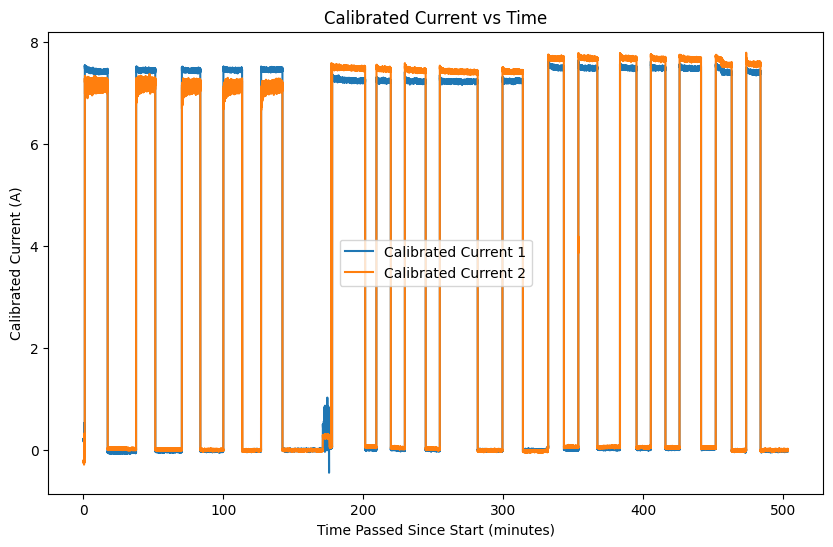

In [283]:
plt.figure(figsize=(10, 6))
plt.plot(cleaned_combined_df['Translated Time (minutes)'], cleaned_combined_df['Calibrated Current 1'], label='Calibrated Current 1')
plt.plot(cleaned_combined_df['Translated Time (minutes)'], cleaned_combined_df['Calibrated Current 2'], label='Calibrated Current 2')
plt.xlabel('Time Passed Since Start (minutes)') 
plt.ylabel('Calibrated Current (A)')
plt.title('Calibrated Current vs Time')
plt.legend()
plt.show()

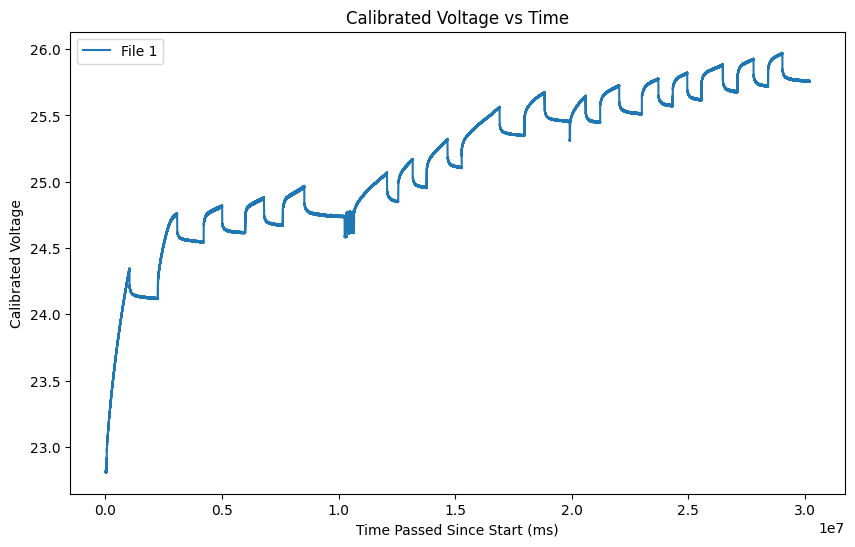

In [282]:
plt.figure(figsize=(10, 6))
plt.plot(cleaned_combined_df['Translated Time'], cleaned_combined_df['Calibrated Voltage'], label='File 1')
plt.xlabel('Time Passed Since Start (ms)')
plt.ylabel('Calibrated Voltage')
plt.title('Calibrated Voltage vs Time')
plt.legend()
plt.show()

In [151]:
# Save to csv
create_output_file(override=True, csv_data=cleaned_combined_df)    